## Lab Objective

In this lab I will use the Ramen Ratings dataset to practice creating data visualizations with Python. I will use Matplotlib and Seaborn to explore patterns in ramen ratings, brands, styles, and countries. The goal is to turn raw data into clear charts that help explain trends and comparisons.

## Setup

First I import the libraries needed for data analysis and visualization. Pandas will help work with the dataset, while Matplotlib and Seaborn will be used to create charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load the Dataset

Now I load the ramen ratings dataset into a pandas DataFrame so I can analyze and visualize the information.

In [2]:
df = pd.read_csv("ramen-ratings.csv")

df.head()

,Brand,Variety,Style,Country,Stars
0,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75
1,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1.00
2,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25
3,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75
4,Ching's Secret,Singapore Curry,Pack,India,3.75


## Exploring the Data

This dataset contains information about different ramen brands, their varieties, packaging style, country of origin, and their star ratings. By exploring the dataset we can understand the structure and see what types of visualizations will be useful.

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2577 entries, 0 to 2576
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    2577 non-null   str    
 1   Variety  2577 non-null   str    
 2   Style    2575 non-null   str    
 3   Country  2577 non-null   str    
 4   Stars    2577 non-null   float64
dtypes: float64(1), str(4)
memory usage: 100.8 KB


,Stars
count,2577.000000
mean,3.654676
std,1.015331
min,0.000000
25%,3.250000
50%,3.750000
75%,4.250000
max,5.000000


## Creating a Synthetic Year Column

The original dataset does not include a year column. To analyze trends over time, I will create a synthetic year column by randomly assigning years between 2002 and 2017.

In [4]:
import numpy as np

np.random.seed(0)
df["Year"] = np.random.randint(2002, 2018, size=len(df))

df.head()

,Brand,Variety,Style,Country,Stars,Year
0,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,2014
1,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1.00,2017
2,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,2007
3,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,2002
4,Ching's Secret,Singapore Curry,Pack,India,3.75,2005


## Distribution Analysis: Histogram of Star Ratings

This histogram shows how ramen ratings are distributed. It helps show whether most ramen products have high ratings, low ratings, or something in between.

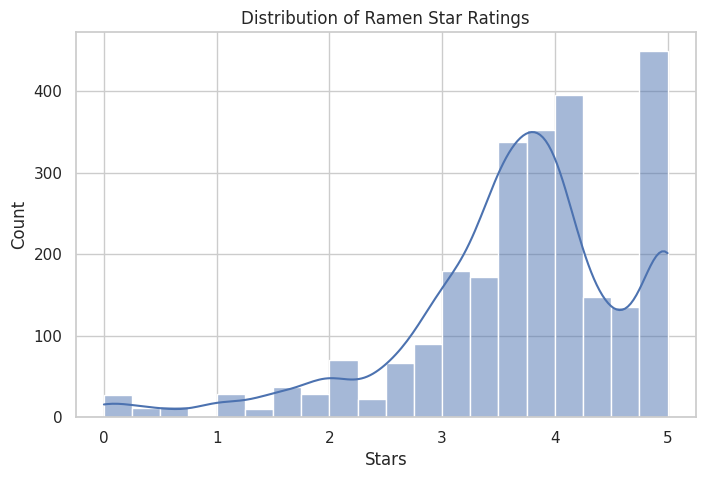

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["Stars"], bins=20, kde=True)
plt.title("Distribution of Ramen Star Ratings")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

Most ramen ratings appear to cluster between about 3 and 4 stars. There are fewer extremely low or extremely high ratings. This shows that most ramen products are rated fairly positively.

## Distribution Analysis: Boxplot of Star Ratings

A boxplot helps show the spread of the ratings, including the median, quartiles, and any possible outliers.

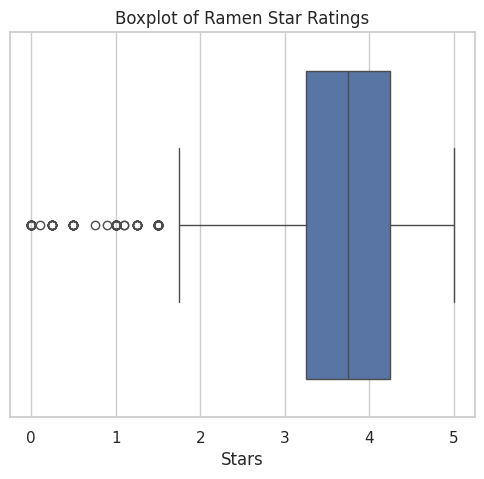

In [6]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df["Stars"])
plt.title("Boxplot of Ramen Star Ratings")
plt.show()

The boxplot shows that most ratings are between about 3 and 4 stars. There are some lower outliers where ramen received very low scores. This suggests that while most ramen is rated well, a few products perform poorly.

## Comparison: Top 10 Brands by Number of Varieties

This chart shows which ramen brands have the most product varieties in the dataset.

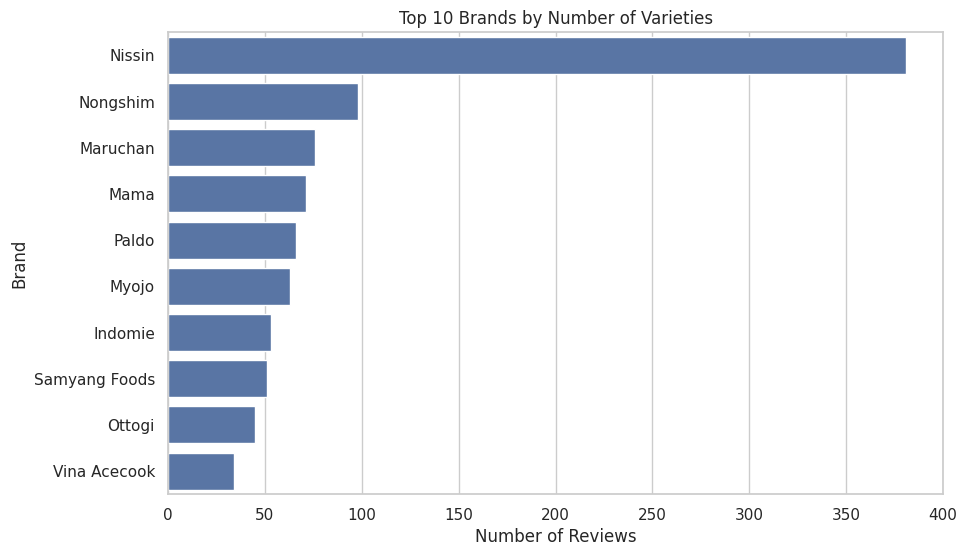

In [7]:
top_brands = df["Brand"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title("Top 10 Brands by Number of Varieties")
plt.xlabel("Number of Reviews")
plt.ylabel("Brand")
plt.show()

Some ramen brands appear much more frequently than others in the dataset. This means they likely produce many different varieties of ramen. Popular brands dominate the top positions.

## Comparison: Average Stars by Country

This chart compares the average ramen ratings between different countries.

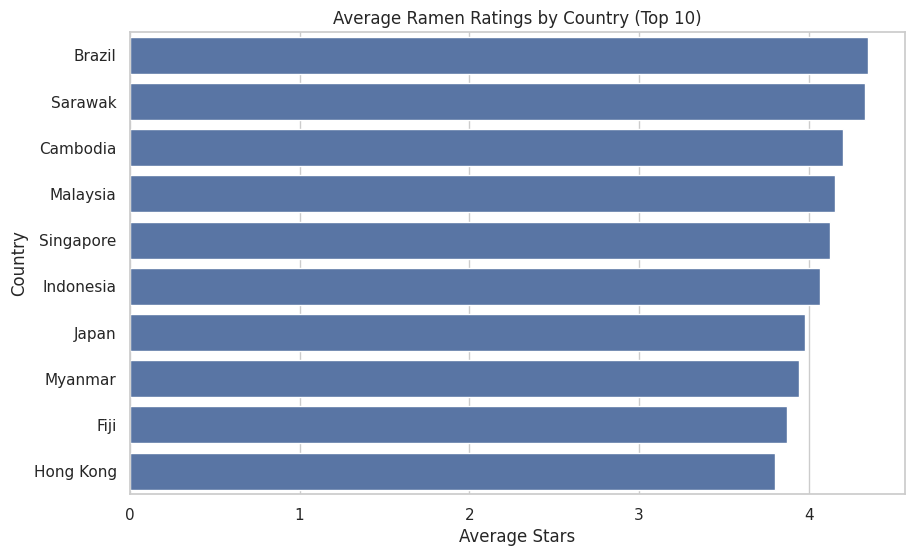

In [8]:
country_avg = df.groupby("Country")["Stars"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=country_avg.values, y=country_avg.index)
plt.title("Average Ramen Ratings by Country (Top 10)")
plt.xlabel("Average Stars")
plt.ylabel("Country")
plt.show()

Some countries have higher average ramen ratings than others. This suggests that certain regions may produce ramen that reviewers like more. It may also reflect differences in ramen styles or quality.

## Comparison: Average Stars by Style

This chart compares average ratings based on the ramen packaging style.

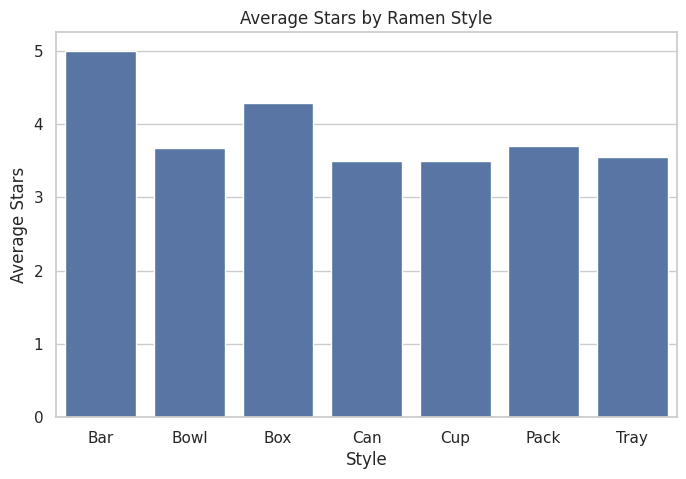

In [9]:
style_avg = df.groupby("Style")["Stars"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=style_avg.index, y=style_avg.values)
plt.title("Average Stars by Ramen Style")
plt.xlabel("Style")
plt.ylabel("Average Stars")
plt.show()

Different ramen packaging styles have slightly different average ratings. Some styles appear to perform better than others. This could be related to how the ramen is prepared or packaged.

## Comparison: Style Distribution by Country

This chart shows how ramen styles are distributed across the top countries.

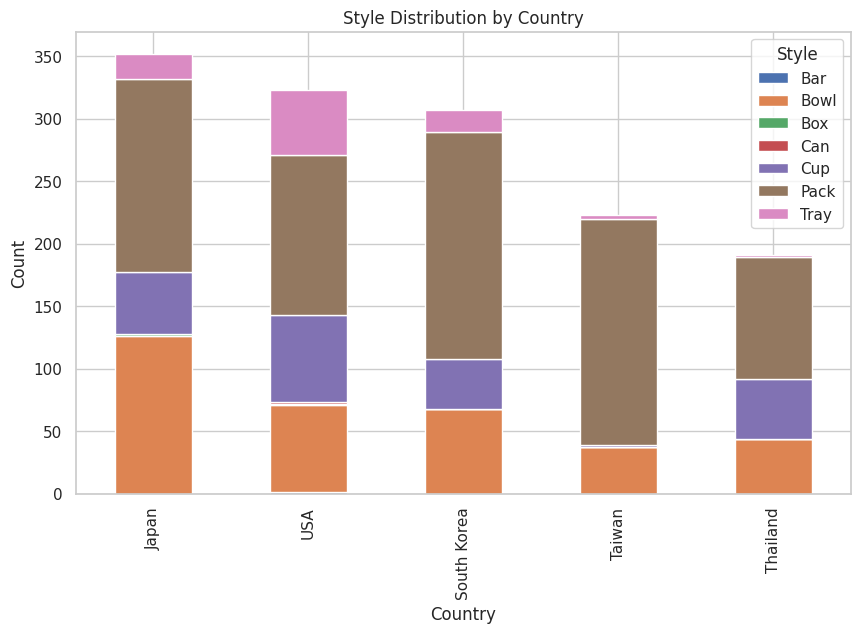

In [10]:
top_countries = df["Country"].value_counts().head(5).index
style_country = pd.crosstab(df["Country"], df["Style"]).loc[top_countries]

style_country.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Style Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

Different countries tend to have different popular ramen styles. Some countries have more cup-style ramen while others have more packet styles. This shows cultural differences in packaging and consumption.

## Comparison: Number of Reviews by Style

This chart shows how many reviews exist for each ramen style.

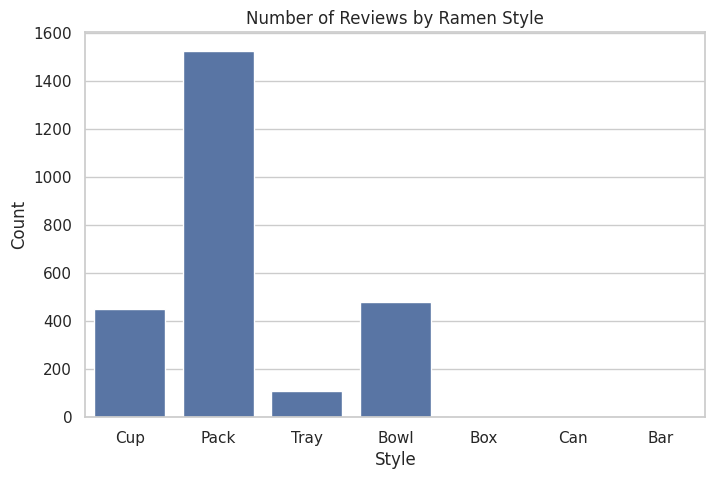

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Style")
plt.title("Number of Reviews by Ramen Style")
plt.xlabel("Style")
plt.ylabel("Count")
plt.show()

Some ramen styles appear much more frequently in the dataset. Packet and cup styles seem to have the highest number of reviews. This likely reflects their popularity in the market.

## Comparison: Highest Rated Brands

This lollipop chart shows the brands with the highest average star ratings.

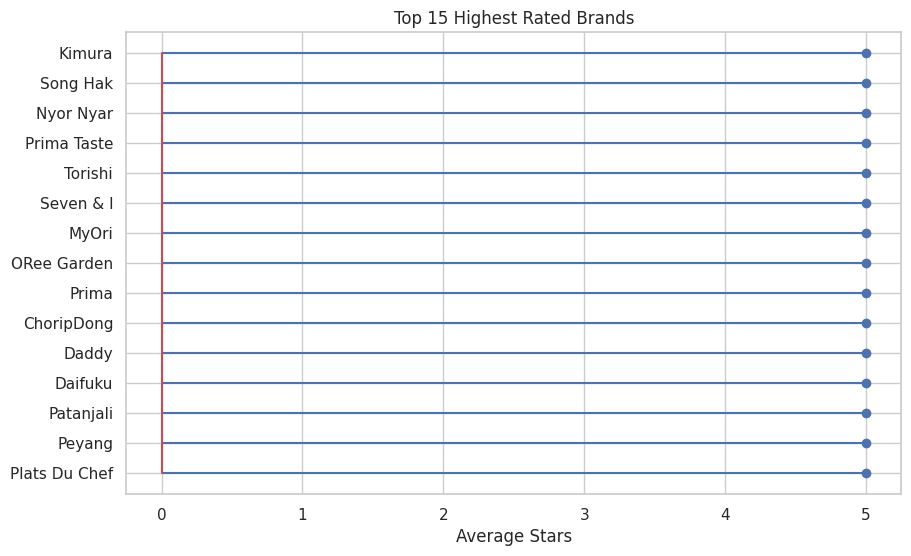

In [12]:
brand_avg = df.groupby("Brand")["Stars"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.stem(brand_avg.values, orientation='horizontal')
plt.yticks(range(len(brand_avg)), brand_avg.index)
plt.title("Top 15 Highest Rated Brands")
plt.xlabel("Average Stars")
plt.show()

Some brands consistently receive higher ratings than others. These brands may focus more on quality or flavor. The chart makes it easy to see which brands perform the best.

## Relationship: Year vs Star Ratings

This scatter plot shows how ramen ratings relate to the review year.

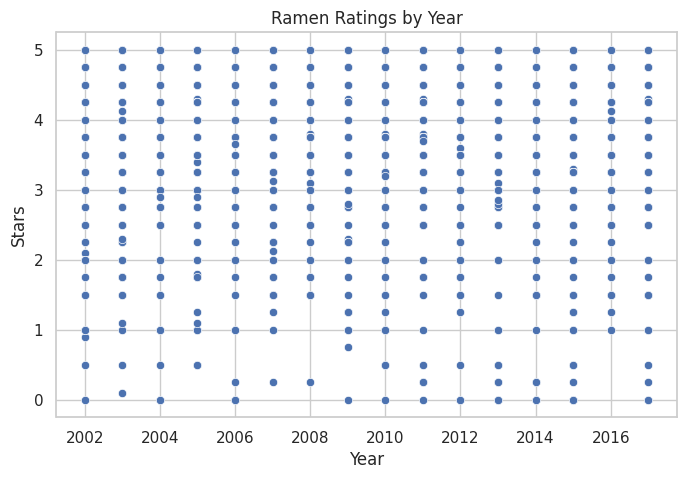

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Year", y="Stars")
plt.title("Ramen Ratings by Year")
plt.show()

The ratings appear fairly spread across the years. There is no obvious strong pattern where ratings increase or decrease over time. This suggests ramen ratings have stayed relatively stable.

## Trend Analysis: Average Ratings by Year

This line chart shows the average ramen rating for each year.

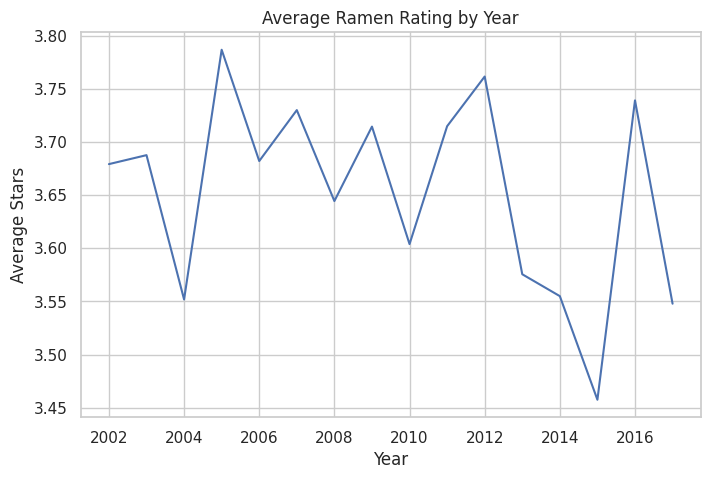

In [14]:
year_avg = df.groupby("Year")["Stars"].mean()

plt.figure(figsize=(8,5))
sns.lineplot(x=year_avg.index, y=year_avg.values)
plt.title("Average Ramen Rating by Year")
plt.xlabel("Year")
plt.ylabel("Average Stars")
plt.show()

The average ratings fluctuate slightly from year to year. However, there is no large trend of ratings drastically increasing or decreasing. This suggests overall ramen quality has stayed fairly consistent.

## Relationship: Country vs Style Heatmap

This heatmap shows the average ratings for combinations of countries and ramen styles.

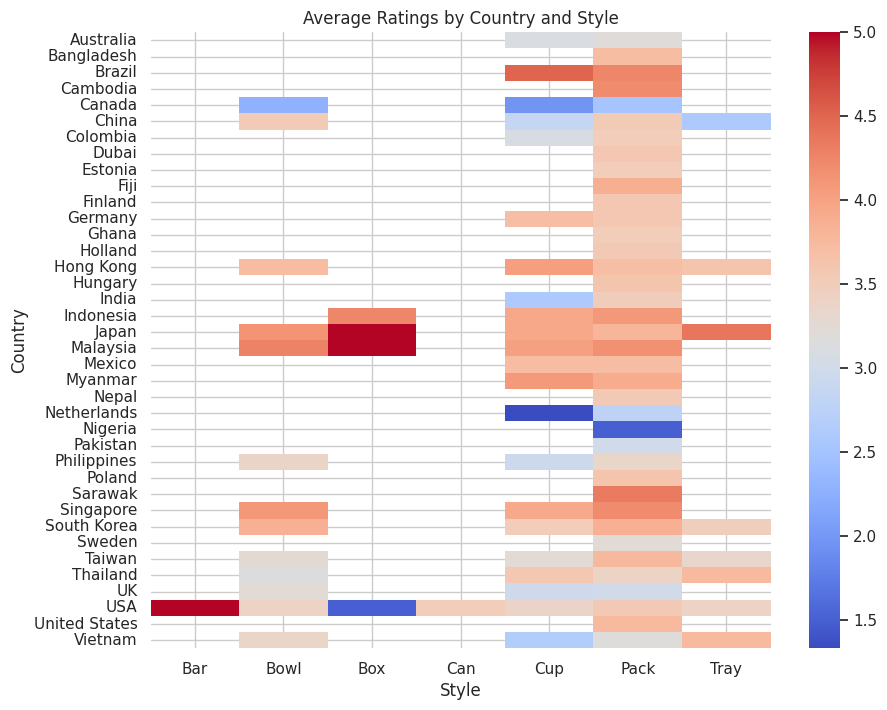

In [15]:
heatmap_data = df.pivot_table(values="Stars", index="Country", columns="Style", aggfunc="mean")

plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data, cmap="coolwarm")
plt.title("Average Ratings by Country and Style")
plt.show()

The heatmap shows how ratings vary depending on both the country and the style of ramen. Some combinations appear to perform better than others. This helps highlight patterns that would be difficult to see in raw data.

## Final Reflection

The chart that helped me the most was the heatmap because it showed relationships between multiple variables at once. It made it easier to see patterns between countries and ramen styles. One surprising thing was how consistent most ramen ratings were, with many around 3 to 4 stars. Visualizations made it much easier to understand the dataset compared to just looking at rows of numbers. Charts helped highlight trends, comparisons, and patterns quickly.